In [600]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
library(randomForest)
library(pheatmap)
library(dbscan)
library(scDblFinder)
library(Matrix)

suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

Sys.setenv(
  http_proxy  = "http://10.10.50.114:45698",
  https_proxy = "http://10.10.50.114:45698"
)


# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [ ]:
h5ad_path <- "/home/chaiqw/project/mb/GSE168156_merged_CC20230722_full_mapping.h5ad"
output_rds <- "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/RAT_VTA_dataset.rds"
output_feature_map <- "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/RAT_feature_map.csv"

data1 <- read_h5ad(h5ad_path)

counts <- Matrix::t(data1$X)
metadata <- as.data.frame(data1$obs)
feature_metadata <- as.data.frame(data1$var)

stopifnot(nrow(counts) == nrow(feature_metadata))
stopifnot(ncol(counts) == nrow(metadata))

cell_ids <- rownames(metadata)
rat_ensembl_id <- as.character(feature_metadata$gene_id)
rat_gene_name <- as.character(feature_metadata$gene_name)


gene_symbol_upper <- toupper(trimws(rat_gene_name))
keep <- !is.na(gene_symbol_upper) & gene_symbol_upper != ""

counts <- counts[keep, , drop = FALSE]
rat_ensembl_id <- rat_ensembl_id[keep]
rat_gene_name <- rat_gene_name[keep]
gene_symbol_upper <- gene_symbol_upper[keep]


unique_symbols <- unique(gene_symbol_upper)
feature_to_symbol <- Matrix::sparseMatrix(
  i = match(gene_symbol_upper, unique_symbols),
  j = seq_along(gene_symbol_upper),
  x = 1,
  dims = c(length(unique_symbols), length(gene_symbol_upper))
)

counts <- feature_to_symbol %*% counts
rownames(counts) <- unique_symbols
colnames(counts) <- cell_ids

# %%
seurat1 <- CreateSeuratObject(
  counts = counts,
  meta.data = metadata,
  project = "GSE168156_rat_VTA"
)

feature_map <- data.frame(
  rat_ensembl_id = rat_ensembl_id,
  rat_gene_name = rat_gene_name,
  gene_symbol_upper = gene_symbol_upper
)

write.csv(feature_map, output_feature_map, row.names = FALSE)
saveRDS(seurat1, output_rds)

print(seurat1)
head(rownames(seurat1))

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


An object of class Seurat 
28914 features across 21606 samples within 1 assay 
Active assay: RNA (28914 features, 0 variable features)
 1 layer present: counts


[1] "AABR07000046.1" "AABR07000089.1" "VOM2R6"         "VOM2R5"        
[5] "RAET1E"         "RF00421"

In [6]:
# data1 = read_h5ad('/home/chaiqw/project/mb/GSE168156_merged_CC20230722_full_mapping.h5ad')
# seurat1 = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)

seurat2  = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260807_VTA_DA_seurat_cluster.rds')


In [9]:
seurat1$class %>% unique()

[1] 31 OPC-Oligo    16 HY MM Glut   34 Immune       26 P GABA      
 [5] 14 HY Glut      20 MB GABA      30 Astro-Epen   19 MB Glut     
 [9] 21 MB Dopa      24 MY Glut      23 P Glut       33 Vascular    
[13] 12 HY GABA      01 IT-ET Glut   22 MB-HB Sero   11 CNU-HYa GABA
[17] 27 MY GABA      03 OB-CR Glut   05 OB-IMN GABA  18 TH Glut     
[21] 13 CNU-HYa Glut 29 CB Glut      09 CNU-LGE GABA 08 CNU-MGE GABA
[25] 07 CTX-MGE GABA 10 LSX GABA     06 CTX-CGE GABA 32 OEC         
[29] 28 CB GABA      04 DG-IMN Glut 
30 Levels: 01 IT-ET Glut 03 OB-CR Glut 04 DG-IMN Glut ... 34 Immune

In [32]:
seurat1_sub = subset(seurat1, class == "21 MB Dopa" & class_probability > 0.8)
seurat1_sub

An object of class Seurat 
28914 features across 465 samples within 1 assay 
Active assay: RNA (28914 features, 0 variable features)
 1 layer present: counts

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony converged after 1 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There i

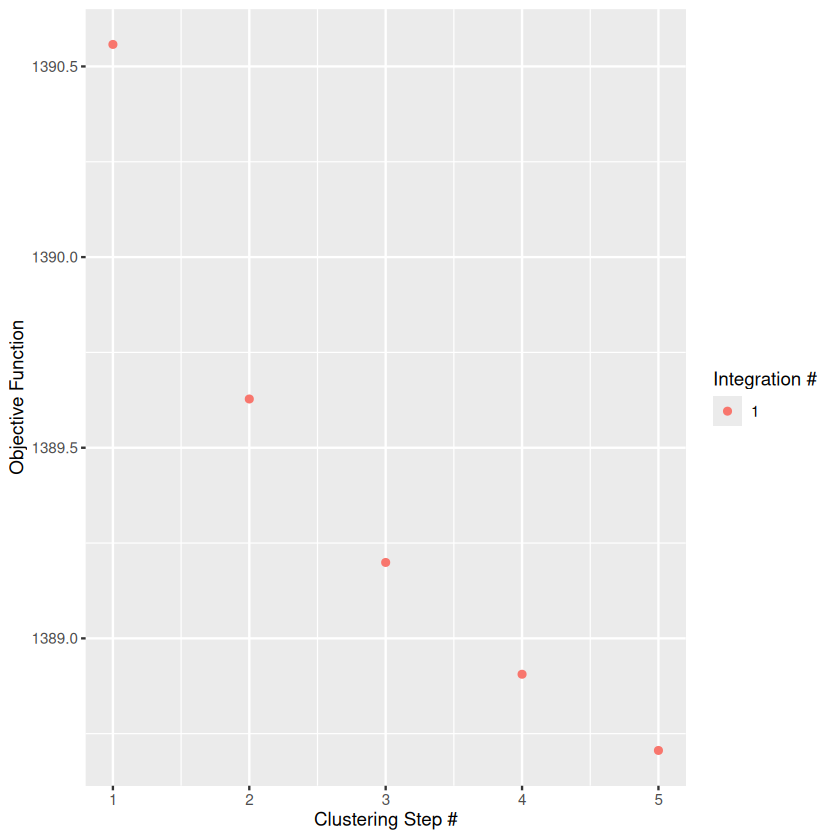

In [35]:
class_resolution = 0.1

seurat1_sub$Animal = seurat1_sub$gsm_id
mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = seurat1_sub@assays$RNA$counts
meta = seurat1_sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

seurat1_sub1 = CreateSeuratObject(counts = new_assay)
seurat1_sub1 = AddMetaData(seurat1_sub1, meta)

seurat1_sub1 = NormalizeData(seurat1_sub1, normalization.method = "LogNormalize", scale.factor = 10000)
seurat1_sub1 = FindVariableFeatures(seurat1_sub1, selection.method = "vst", nfeatures = 3000)
seurat1_sub1 = ScaleData(seurat1_sub1, features = rownames(seurat1_sub1))

seurat1_sub1 = seurat1_sub1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

seurat1_sub1 = RunHarmony(
    seurat1_sub1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

seurat1_sub1 = seurat1_sub1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

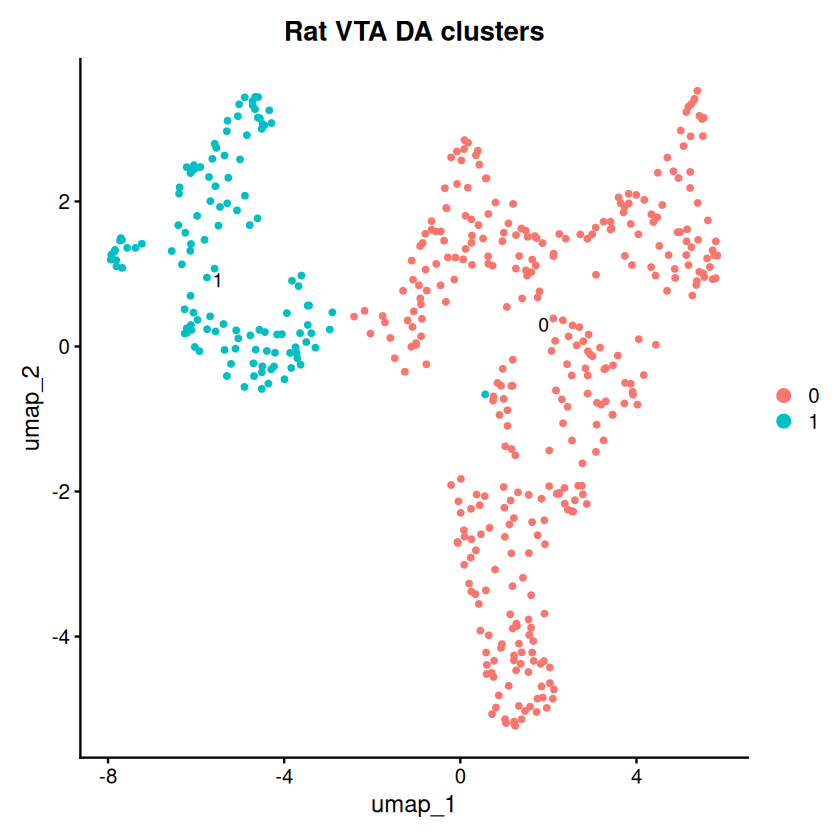

In [52]:
options(repr.plot.width=7, repr.plot.height=7)

DimPlot(seurat1_sub1, reduction = "umap", group.by = "seurat_clusters", label = TRUE, repel = TRUE) + ggtitle("Rat VTA DA clusters")

In [55]:
table(seurat1_sub1$seurat_clusters)


  0   1 
340 125 

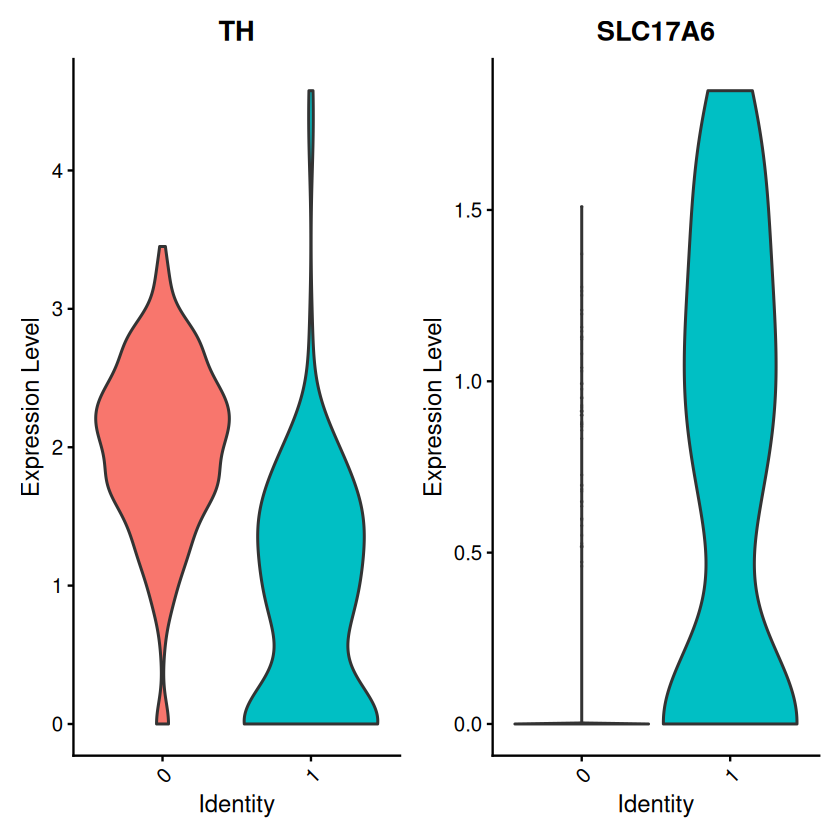

In [56]:
DefaultAssay(seurat1_sub1) <- "RNA"

VlnPlot(
    seurat1_sub1,
    features = c("TH", "SLC17A6"),
    group.by = "seurat_clusters",
    pt.size = 0,
    ncol = 2
)

In [57]:
seurat1_sub1_filt = subset(seurat1_sub1, seurat_clusters %in% c(0))
seurat1_sub1_filt

An object of class Seurat 
28914 features across 340 samples within 1 assay 
Active assay: RNA (28914 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [477]:
saveRDS(seurat1_sub1_filt, "/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260825_VTA_rat_DA_seurat_cluster.rds")

Normalizing layer: counts



Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony converged after 1 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random 

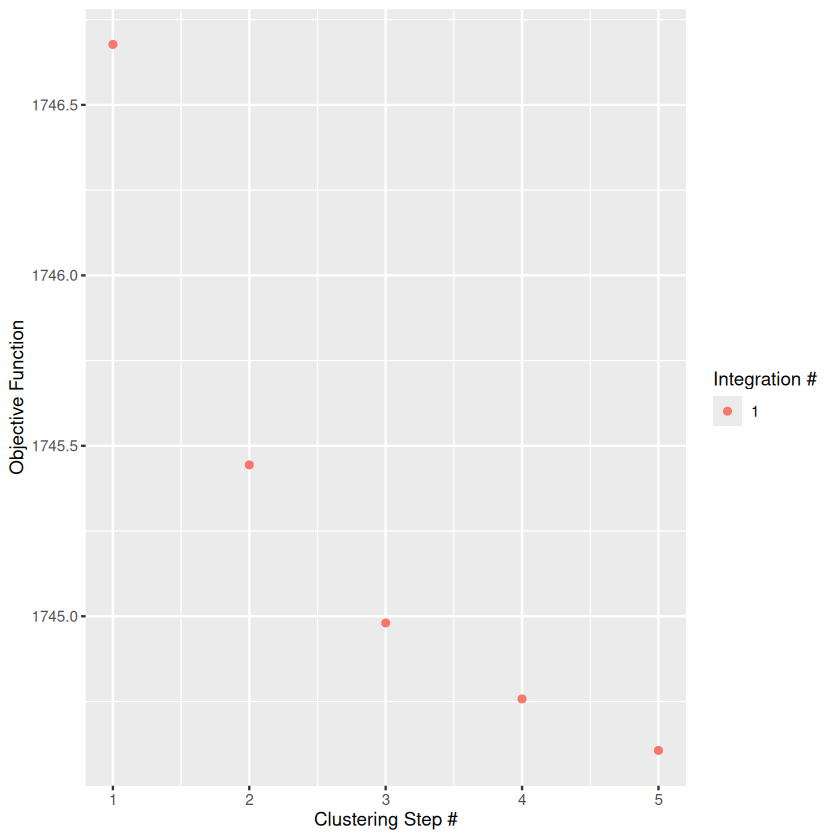

In [338]:
class_resolution = 1.2


mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = seurat1_sub1_filt@assays$RNA$counts
meta = seurat1_sub1_filt@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

seurat1_sub1_filt1 = CreateSeuratObject(counts = new_assay)
seurat1_sub1_filt1 = AddMetaData(seurat1_sub1_filt1, meta)

seurat1_sub1_filt1 = NormalizeData(seurat1_sub1_filt1, normalization.method = "LogNormalize", scale.factor = 10000)
seurat1_sub1_filt1 = FindVariableFeatures(seurat1_sub1_filt1, selection.method = "vst", nfeatures = 3000)
seurat1_sub1_filt1 = ScaleData(seurat1_sub1_filt1, features = rownames(seurat1_sub1_filt1))

seurat1_sub1_filt1 = seurat1_sub1_filt1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

seurat1_sub1_filt1 = RunHarmony(
    seurat1_sub1_filt1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

seurat1_sub1_filt1 = seurat1_sub1_filt1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

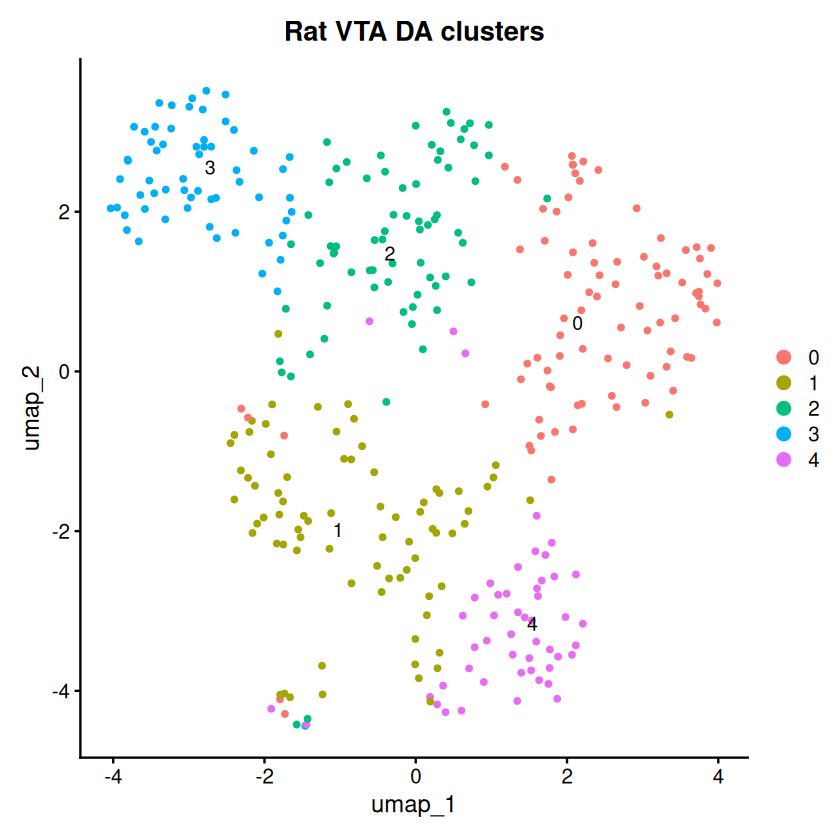

In [342]:
options(repr.plot.width=7, repr.plot.height=7)

DimPlot(seurat1_sub1_filt1, reduction = "umap", group.by = "seurat_clusters", label = TRUE, repel = TRUE) + ggtitle("Rat VTA DA clusters")

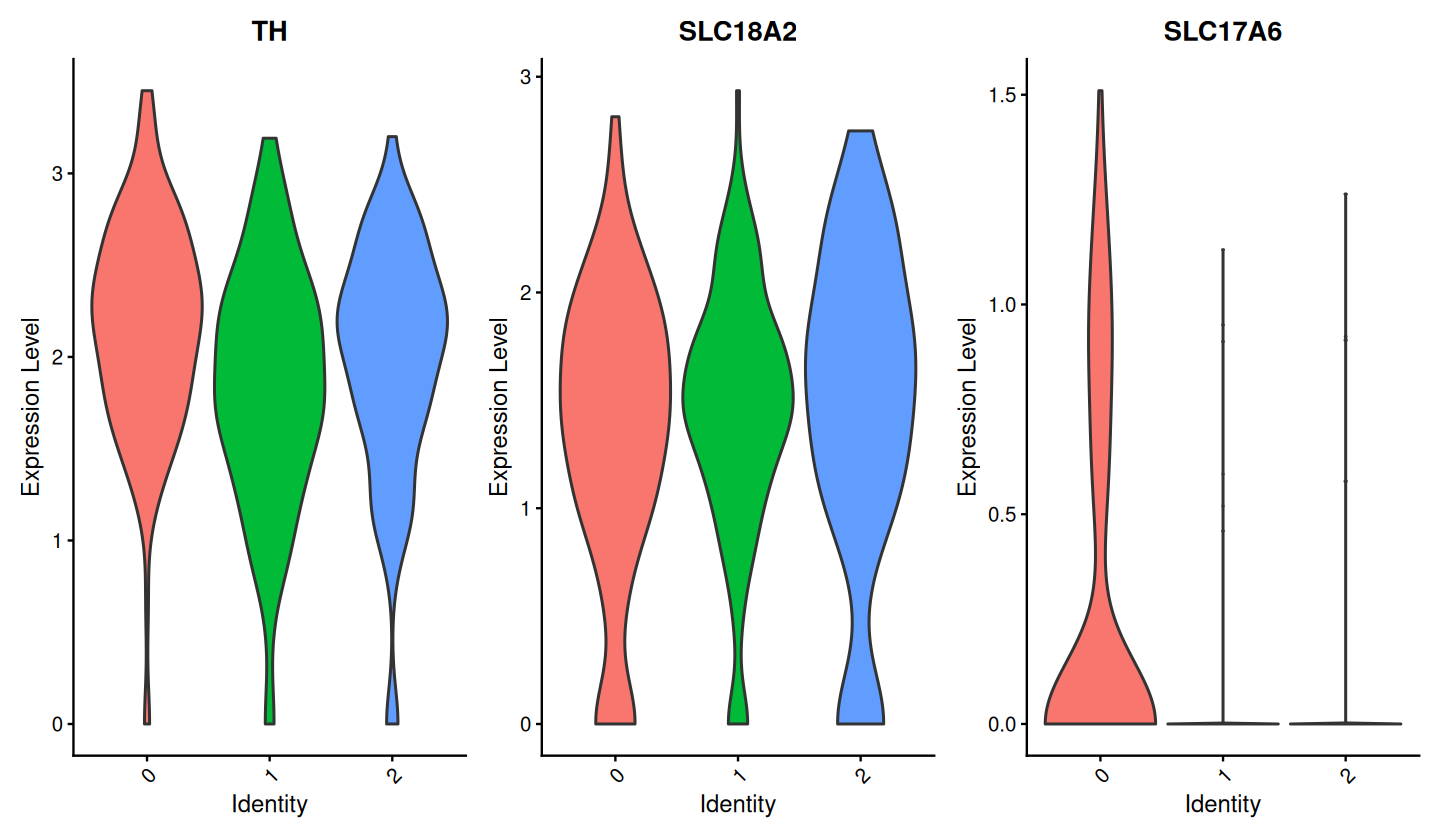

In [117]:
DefaultAssay(seurat1_sub1_filt1) <- "RNA"
options(repr.plot.width=12, repr.plot.height=7)
VlnPlot(
    seurat1_sub1_filt1,
    features = c("TH", 'SLC18A2',"SLC17A6"),
    group.by = "seurat_clusters",
    pt.size = 0,
    ncol = 3
)

In [76]:
seurat1_sub1_filt1$cluster = paste('DA', seurat1_sub1_filt1$seurat_clusters, sep = '_')

table(seurat1_sub1_filt1$cluster)


DA_0 DA_1 DA_2 
 132  122   86 

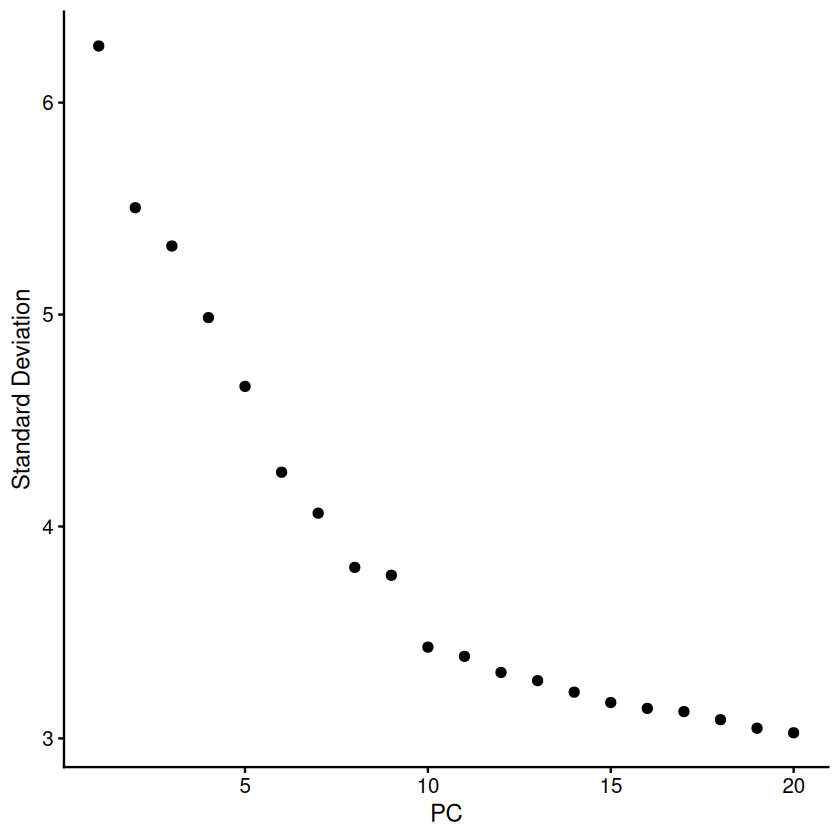

In [337]:
ElbowPlot(seurat1_sub1_filt1)

In [415]:
Idents(seurat2) <- "cluster"
DA = subset(seurat2, downsample = 38)
DA

An object of class Seurat 
20344 features across 342 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony converged after 1 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There i

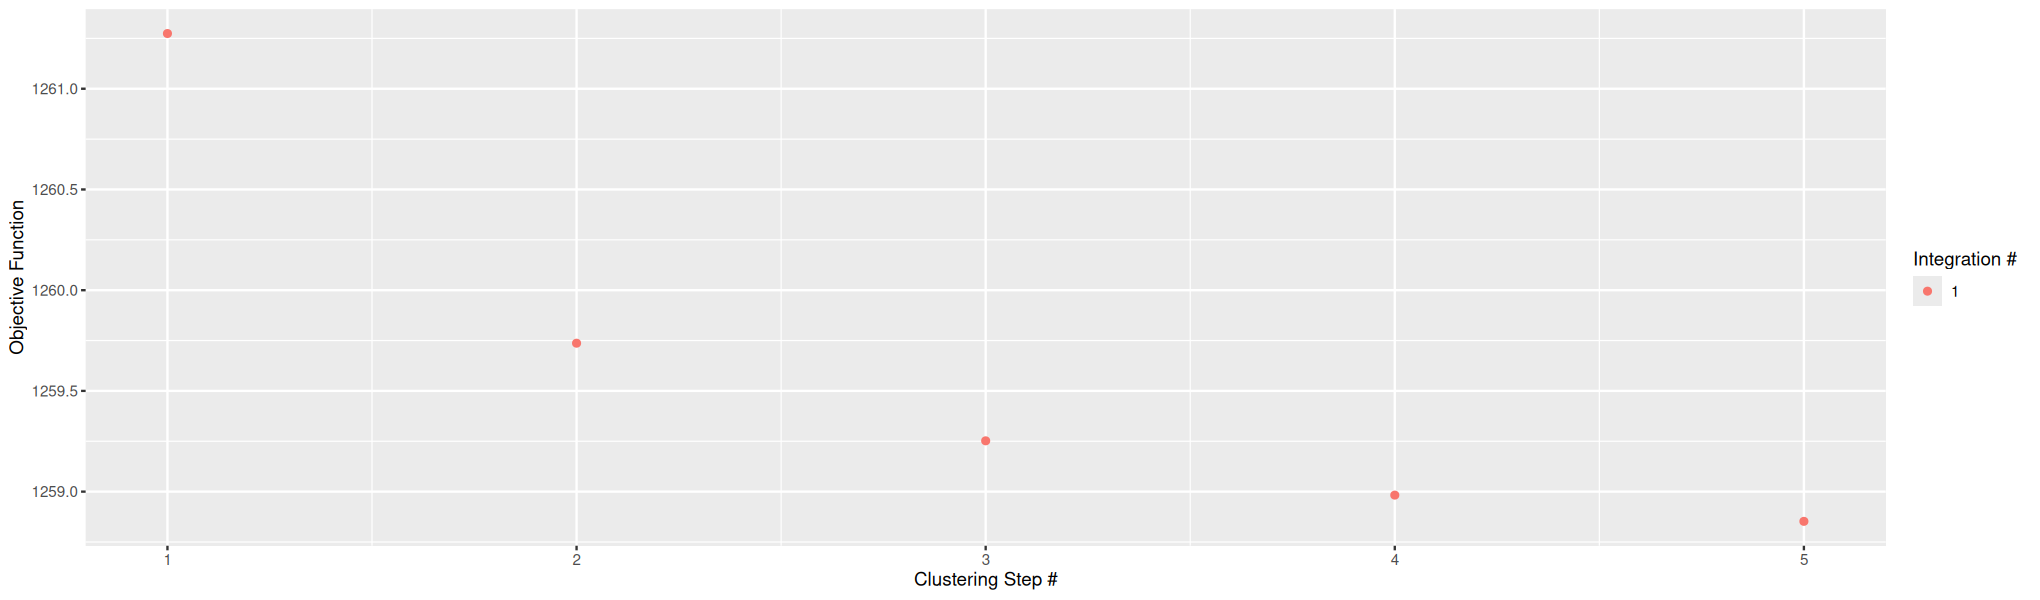

In [416]:
Idents(seurat2) <- "cluster"
DA = subset(seurat2, downsample = 38)

class_resolution = 0.5

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

sub = DA

assay = sub@assays$RNA$counts
meta = sub@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

sub = CreateSeuratObject(counts = new_assay)
sub = AddMetaData(sub, meta)

sub = NormalizeData(sub, normalization.method = "LogNormalize", scale.factor = 10000)
sub = FindVariableFeatures(sub, selection.method = "vst", nfeatures = 3000)
sub = ScaleData(sub, features = rownames(sub))

sub = sub %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

sub = RunHarmony(
    sub, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

sub = sub %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

In [ ]:
seurat1_sub1_filt1$species = "rat"
seurat1_sub1_filt1$Cluster = paste0("rat_", seurat1_sub1_filt1$cluster)
# seurat1_sub1_filt1$cluster = seurat1_sub1_filt1$seurat_clusters
sub$species = "macaque"
sub$Cluster = paste0("macaque_", sub$cluster)

# 创建整合列表
seurat_list <- list(rat = seurat1_sub1_filt1, mq = sub)

# 两个数据集各自高变基因的交集
features <- Reduce(intersect, lapply(seurat_list, VariableFeatures))
if (length(features) == 0) {
  stop("No shared variable features were found between rat and macaque datasets.")
}
message("Shared variable features: ", length(features))

# 使用 CCA 方法找整合锚点
anchors <- FindIntegrationAnchors(
  object.list = seurat_list,
  anchor.features = features,
  reduction = "cca"
 )

# 整合数据
integrated_data <- IntegrateData(anchorset = anchors)

Shared variable features: 1029

Scaling features for provided objects



Warning message:
“Different features in new layer data than already exists for scale.data”
Warning message:
“Different features in new layer data than already exists for scale.data”
Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 1289 anchors

Filtering anchors

	Retained 965 anchors

Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [ ]:
DefaultAssay(integrated_data) <- "integrated"

integrated_data <- ScaleData(integrated_data)
integrated_data <- RunPCA(integrated_data, npcs = 50)
integrated_data <- RunUMAP(integrated_data, dims = 1:25)

integrated_data <- FindNeighbors(integrated_data, dims = 1:25)
integrated_data <- FindClusters(integrated_data, resolution = 2)


Centering and scaling data matrix



PC_ 1 
Positive:  KCNJ6, KIF26B, KCND3, CLSTN2, AUTS2, CALN1, RNF150, PLCB1, PRKCA, NEK10 
	   ARHGAP6, COL25A1, FMN1, PID1, NRG1, TMEM132C, DOK6, DGKI, GPR158, CACNB4 
	   PLCB4, FAM135B, DAB1, KIRREL3, HS6ST3, ROBO1, RAI14, RGS6, STK39, MTUS2 
Negative:  PEBP1, UBB, NEFL, SNCG, NEFM, ACTB, TUBB2A, TUBB4B, NDUFS5, CFL1 
	   NEFH, NDUFB10, COX7B, COX6B1, MBP, PSMB10, GLUL, ATP6V1F, SPP1, OLFM1 
	   CST3, CLU, PCDH17, HAPLN4, DAAM2, QDPR, ALDH1A1, SNCB, MYRF, ZCCHC24 
PC_ 2 
Positive:  SV2C, OLFM3, LMO3, PEX5L, RYR3, SOX6, PTPN13, ALDH1A1, COL11A1, PLCH1 
	   PHLDB2, BVES, BNC2, KANK4, CUX2, RORA, MRVI1, ERBB4, IL1RAP, VWC2 
	   PTPRZ1, ITPR1, ANK1, SATB1, OSBPL3, KCND3, KLHL5, ST3GAL1, PXDN, RERG 
Negative:  TRPM3, SLC35F4, KCNH1, SORCS3, GRID2, RELN, GRIK2, MAN1A1, HHAT, SHISA6 
	   KCNAB1, TMTC1, GRIA4, GABRG3, PDE3A, SEMA5A, PDZD2, DKK2, KCNK13, CDH18 
	   FRMD5, NRP2, FOXP2, LUZP2, KCNH5, EPHB1, TMEM132D, CDH4, KCNC2, NETO2 
PC_ 3 
Positive:  TLL1, FRAS1, CNTN6, ANXA3, KANK4, MLLT3

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 690
Number of edges: 26706

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5404
Number of communities: 11
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


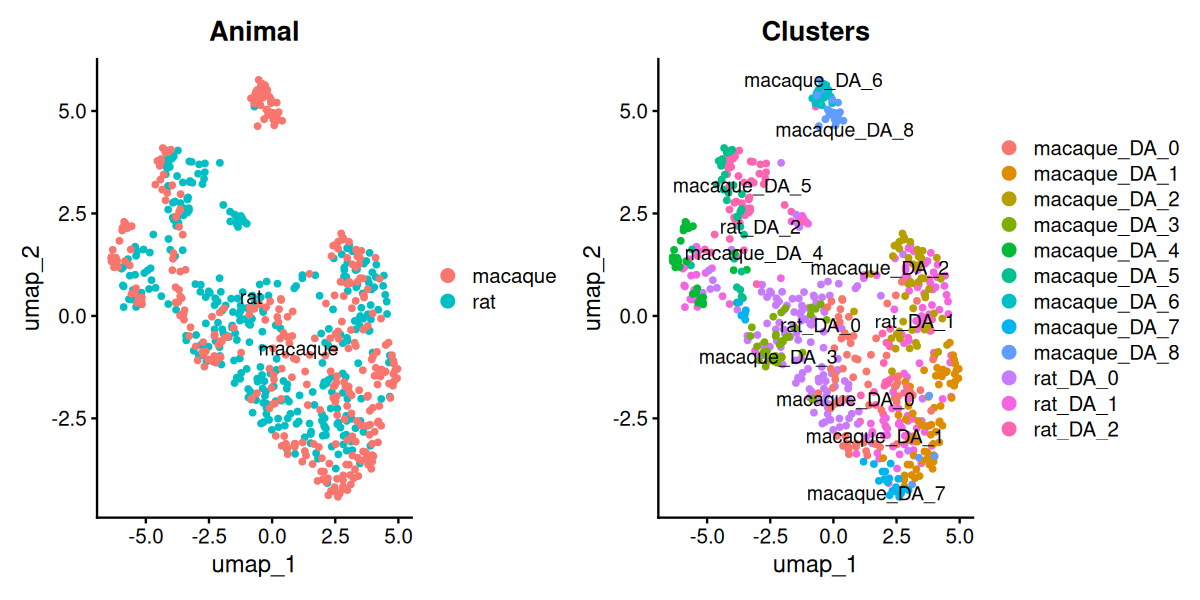

In [99]:
options(repr.plot.width=10, repr.plot.height=5)

# 可视化
p1 <- DimPlot(integrated_data, reduction = "umap", group.by = "species", 
              label = TRUE, repel = TRUE) + 
      ggtitle("Animal")

p2 <- DimPlot(integrated_data, reduction = "umap", group.by = "Cluster", 
              label = TRUE, repel = TRUE) + 
      ggtitle("Clusters")

p1 | p2


In [95]:
pdf("/mnt/90-connectome/Personal/CQW/midbrain/figure/rat_macaque_integrated_umap_species.pdf",
    width = 6, height = 5)

DimPlot(
    integrated_data,
    reduction = "umap",
    group.by = "species",
    label = TRUE,
    repel = TRUE
) + ggtitle("Animal")

dev.off()

agg_record_1581936781 
                    2

In [102]:
pdf(
    "/mnt/90-connectome/Personal/CQW/midbrain/figure/rat_macaque_integrated_umap_clusters.pdf",
    width = 7, height = 5
)

DimPlot(
    integrated_data,
    reduction = "umap",
    group.by = "cluster",
    label = TRUE,
    repel = TRUE
) + ggtitle("Clusters")

dev.off()

agg_record_1952378950 
                    2

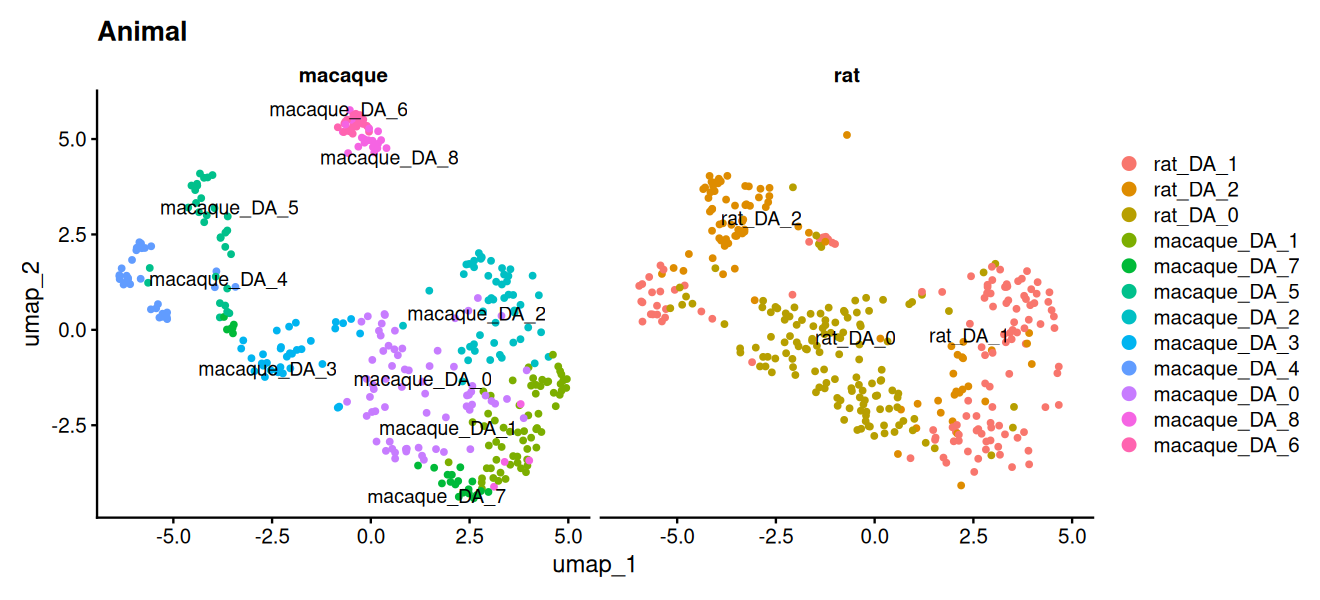

In [535]:
options(repr.plot.width=11, repr.plot.height=5)
Idents(integrated_data) <- "cluster"
DimPlot(integrated_data, reduction = "umap",split.by = "species", 
              label = TRUE, repel = TRUE) + 
      ggtitle("Animal")

In [551]:
pdf(
    "/mnt/90-connectome/Personal/CQW/midbrain/figure/rat_macaque_integrated_umap_clusters_split-1.pdf",
    width = 11, height = 5
)

Idents(integrated_data) <- "cluster"

set.seed(42)
cluster_levels <- levels(Idents(integrated_data))

cluster_colors <- setNames(
  paletteer::paletteer_d(
    "ggsci::category20_d3",
    n = length(cluster_levels)
  ),
  cluster_levels
)

DimPlot(
  integrated_data,
  reduction = "umap",
  split.by = "species",
  label = TRUE,
  repel = TRUE,
  cols = cluster_colors
) +
  ggtitle("Animal")

dev.off()

agg_record_1965996056 
                    2

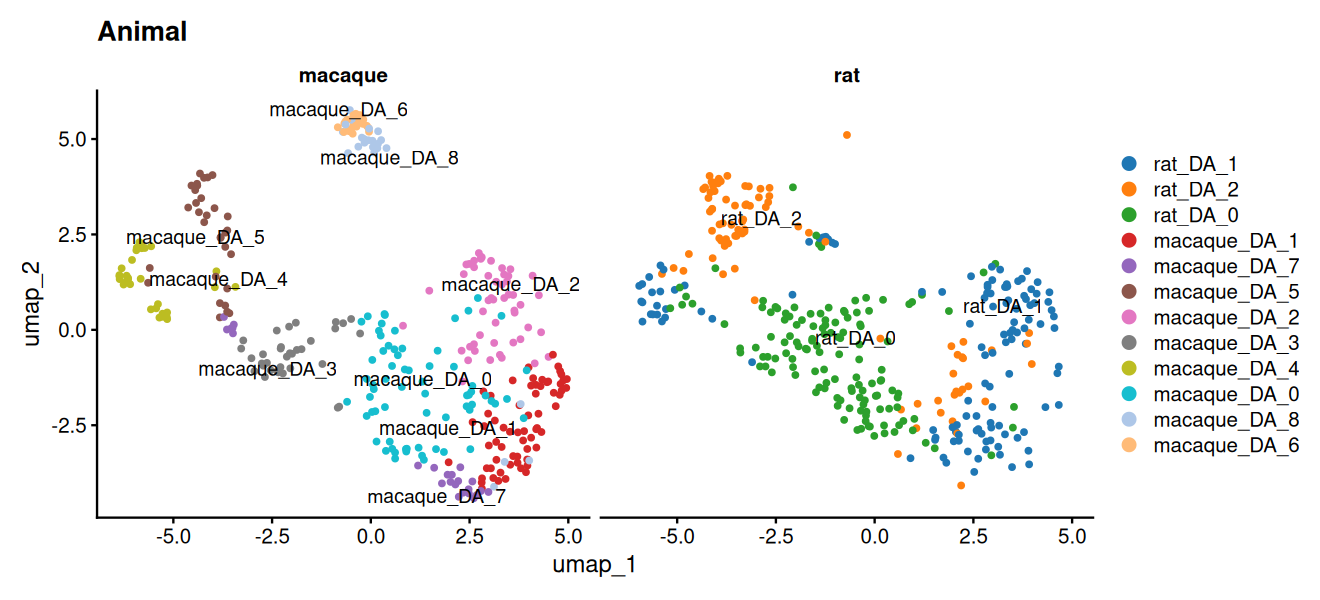

In [550]:
Idents(integrated_data) <- "cluster"

set.seed(42)
cluster_levels <- levels(Idents(integrated_data))

cluster_colors <- setNames(
  paletteer::paletteer_d(
    "ggsci::category20_d3",
    n = length(cluster_levels)
  ),
  cluster_levels
)

DimPlot(
  integrated_data,
  reduction = "umap",
  split.by = "species",
  label = TRUE,
  repel = TRUE,
  cols = cluster_colors
) +
  ggtitle("Animal")

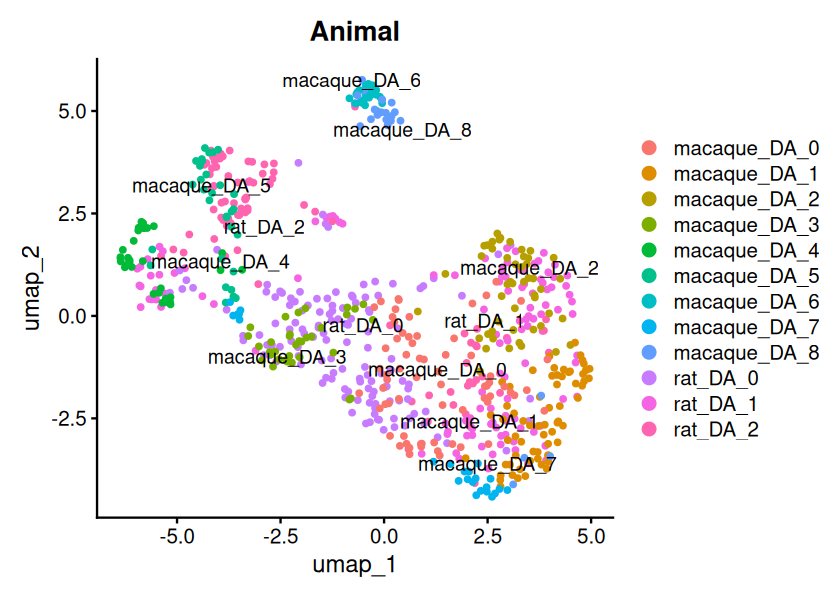

In [533]:
options(repr.plot.width=7, repr.plot.height=5)
Idents(integrated_data) <- "species"
DimPlot(integrated_data, reduction = "umap",group.by = "cluster", 
              label = TRUE, repel = TRUE) + 
      ggtitle("Animal")

In [673]:
saveRDS(
    integrated_data,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/Macaque_Rat_DA_integrated_data.rds"
)

In [562]:
integrated_data_deguse = integrated_data

DefaultAssay(integrated_data_deguse) <- "RNA"
integrated_data_deguse <- JoinLayers(integrated_data_deguse, assay = "RNA")

common_genes <- intersect(
  rownames(seurat1_sub1_filt1[["RNA"]]),  # rat 原始对象
  rownames(sub[["RNA"]])                  # macaque 原始对象
)

length(common_genes)


[1] 13846

In [ ]:

Idents(integrated_data_deguse) <- 'species'

markers <- FindMarkers(
  integrated_data_deguse,
  ident.1 = "macaque",
  ident.2 = "rat",
  assay = "RNA",
  slot = "data",
  features = common_genes,
  test.use = "MAST",
  logfc.threshold = 0.25
)


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!



In [672]:

write.csv(
    markers,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/macaque_vs_rat_markers.csv",
    row.names = TRUE
)

In [564]:
markers_da6_1 <- markers

markers_da6_1$gene <- rownames(markers_da6_1)

# 去除线粒体基因
MTGenes <- c(
  "ND6", "COX1", "ND5", "ND4", "ND2", "ND4L",
  "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1", "COX3"
)

markers_da6_1 <- markers_da6_1[
  !markers_da6_1$gene %in% MTGenes, 
]

# 去除 ENSMFAG 基因
markers_da6_1 <- markers_da6_1 %>%
  filter(!grepl("^ENSMFAG", gene))

# 去除 NA
markers_da6_1 <- markers_da6_1 %>%
  filter(!is.na(p_val_adj), !is.na(avg_log2FC))

In [559]:
markers_da6_1

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CSMD1,4.809876e-253,3.408738,0.923,0.953,1.703273e-248,CSMD1
KAZN,5.540963e-240,4.617759,0.943,0.547,1.962166e-235,KAZN
PBX1,5.613336e-231,3.165654,0.966,0.903,1.987795e-226,PBX1
AABR07000398.1,1.631777e-208,-13.147071,0.000,1.000,5.778449e-204,AABR07000398.1
AC134224.3,1.631777e-208,-17.617314,0.000,1.000,5.778449e-204,AC134224.3
SNHG11,1.631777e-208,-13.720630,0.000,1.000,5.778449e-204,SNHG11
AC134224.1,5.219590e-206,-12.630438,0.000,0.997,1.848361e-201,AC134224.1
AABR07057765.1,1.061285e-199,-12.376018,0.000,0.988,3.758223e-195,AABR07057765.1
MAPT,1.061285e-199,-11.395000,0.000,0.988,3.758223e-195,MAPT


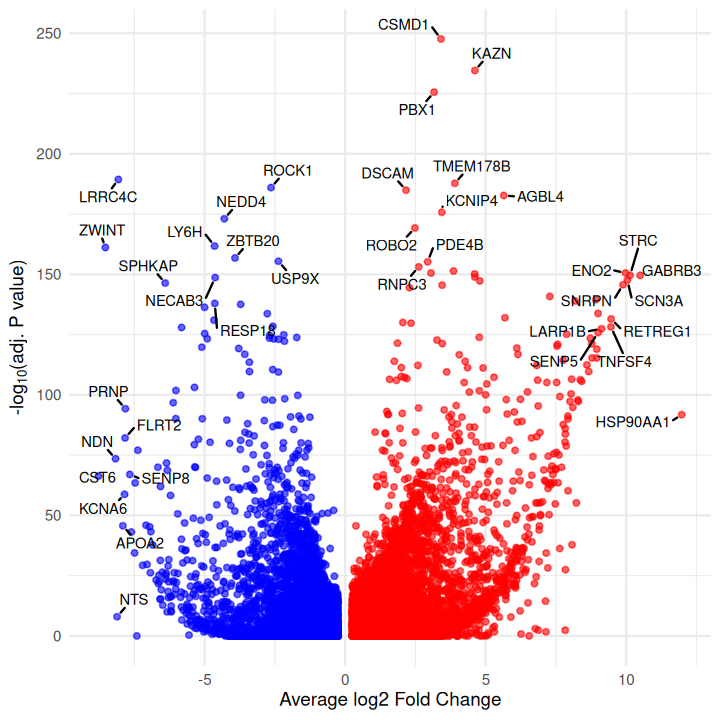

In [565]:
options(repr.plot.width = 6, repr.plot.height = 6)

# p值为0时做特殊处理，方便-log10
markers_da6_1$p_val_adj_plot <- ifelse(markers_da6_1$p_val_adj == 0, 1e-300, markers_da6_1$p_val_adj)

# 上调（logFC>0）基因，选择logFC前10和p值前10
up_logfc_top10 <- markers_da6_1 %>%
  filter(avg_log2FC > 0) %>%
  arrange(desc(avg_log2FC)) %>%
  slice_head(n = 10)

up_pval_top10 <- markers_da6_1 %>%
  filter(avg_log2FC > 0) %>%
  arrange(p_val_adj) %>%
  slice_head(n = 10)

# 下调（logFC<0）基因，选择logFC前10和p值前10
down_logfc_top10 <- markers_da6_1 %>%
  filter(avg_log2FC < 0) %>%
  arrange(avg_log2FC) %>%
  slice_head(n = 10)

down_pval_top10 <- markers_da6_1 %>%
  filter(avg_log2FC < 0) %>%
  arrange(p_val_adj) %>%
  slice_head(n = 10)

# 合并所有需要标注的基因，去重
top_labels <- bind_rows(up_logfc_top10, up_pval_top10, down_logfc_top10, down_pval_top10) %>%
  distinct(gene, .keep_all = TRUE)

# 标记红色为上调基因（logFC > 0），蓝色为下调基因
markers_da6_1$color_group <- ifelse(markers_da6_1$avg_log2FC > 0, "Up", "Down")

ggplot(markers_da6_1, aes(x = avg_log2FC, y = -log10(p_val_adj_plot))) +
  geom_point(aes(color = color_group), alpha = 0.6, size = 1.2) +
  scale_color_manual(values = c("Up" = "red", "Down" = "blue")) +
  geom_text_repel(
    data = top_labels,
    aes(label = gene),
    color = "black",
    size = 3,
    box.padding = 0.4,
    point.padding = 0.3,
    min.segment.length = 0,
    max.overlaps = Inf
  ) +
  labs(
    x = "Average log2 Fold Change",
    y = expression('-log'[10]*'(adj. P value)')
  ) +
  theme_minimal() +
  theme(legend.position = "none"
  )


In [611]:
markers_da6_1_sub <- markers_da6_1 %>% 
subset(p_val_adj < 1e-50 & abs(avg_log2FC) >2 ) %>% 
group_by(color_group) %>% 
top_n(n = 200, wt = abs(avg_log2FC))


table(markers_da6_1_sub$color_group)


Down   Up 
 146  200 

In [612]:
gene_list_up_1 <- split(markers_da6_1_sub$gene, markers_da6_1_sub$color_group)
# gene_list_up_1

In [617]:
library(enrichR)
gene_list_up_1 = gene_list_up_1[sapply(gene_list_up_1, length) > 0]
lapply(names(gene_list_up_1), function(x){
  enrichr(gene_list_up_1[[x]], c("KEGG_2026"))$KEGG_2026 %>%
    mutate(seurat_clusters = x)
}) %>% bind_rows() -> GO_df_up1

Uploading data to Enrichr... Done.
  Querying KEGG_2026... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying KEGG_2026... Done.
Parsing results... Done.


In [671]:
write.csv(
    GO_df_up1,
    "/mnt/90-connectome/Personal/CQW/midbrain/datasets/macaque_DA_top200_KEGG.csv",
    row.names = TRUE
)

In [625]:
subset(GO_df_up1, seurat_clusters == 'Up') %>% head(30)

,Term,Overlap,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes,seurat_clusters
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
189,LONG-TERM DEPRESSION,6/59,2.689336e-05,0.005862752,0,0,11.523245,121.266376,RYR1;PPP2CA;PPP2R1B;GNA11;GNA12;GNAS,Up
190,CHAGAS DISEASE,5/103,3.773236e-03,0.343858295,0,0,5.154893,28.763385,PPP2CA;TGFB1;PPP2R1B;GNA11;GNAS,Up
191,HIPPO SIGNALING PATHWAY,6/155,4.731995e-03,0.343858295,0,0,4.078946,21.836261,PPP2CA;WNT10B;TGFB1;PPP2R1B;CTNNA2;BMP7,Up
192,AMPK SIGNALING PATHWAY,5/121,7.423029e-03,0.404555097,0,0,4.351017,21.333767,PPP2CA;LEPROT;PPP2R1B;MAP3K7;ACACB,Up
193,ABC TRANSPORTERS,3/45,1.026913e-02,0.447733864,0,0,7.163887,32.800669,ABCA6;ABCA9;ABCA7,Up
194,HUMAN PAPILLOMAVIRUS INFECTION,8/328,1.768352e-02,0.562854889,0,0,2.536458,10.234920,PPP2CA;WNT10B;CDK6;PPP2R1B;TERT;COL4A2;GNAS;TCIRG1,Up
195,AMOEBIASIS,4/100,1.807332e-02,0.562854889,0,0,4.188776,16.810890,TGFB1;COL4A2;GNA11;GNAS,Up
196,TGF-BETA SIGNALING PATHWAY,4/109,2.394210e-02,0.652422357,0,0,3.827988,14.286499,PPP2CA;TGFB1;PPP2R1B;BMP7,Up
197,CYTOSKELETON IN MUSCLE CELLS,6/230,2.842272e-02,0.688461542,0,0,2.702872,9.623755,FBN2;MYOM1;CSRP2;COL4A2;COL11A1;ENO2,Up


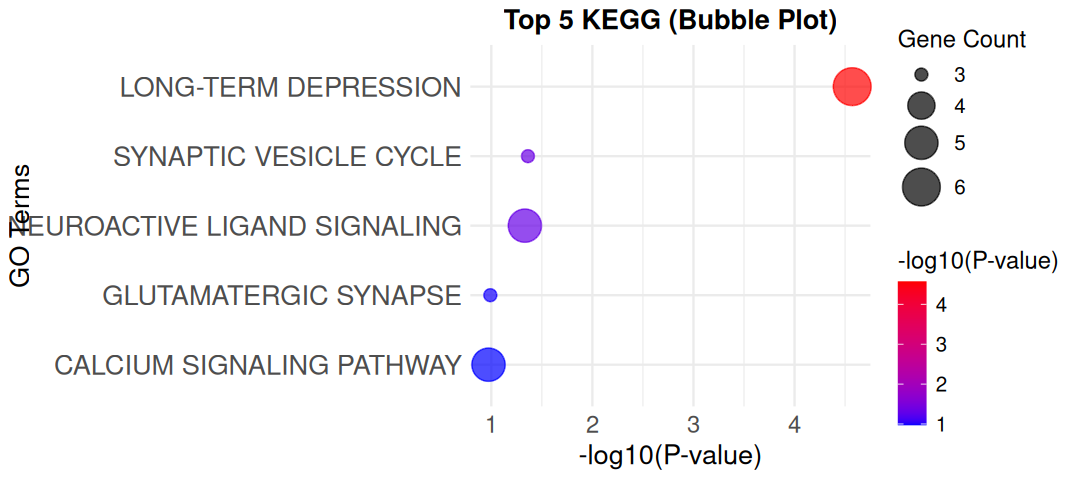

In [629]:
goterm_use = c(
'LONG-TERM DEPRESSION',
'SYNAPTIC VESICLE CYCLE',
'NEUROACTIVE LIGAND SIGNALING',
'GLUTAMATERGIC SYNAPSE',
'CALCIUM SIGNALING PATHWAY'
 )


# Create a bar plot for top 10 GO terms
library(ggplot2)

# Get top 10 GO terms
top10_GO <- GO_df_up1 %>% subset(Term %in% goterm_use & seurat_clusters == 'Up')
options(repr.plot.width=9, repr.plot.height=4)
# Create bubble plot
p2 <- ggplot(top10_GO, aes(x = -log10(P.value), y = reorder(Term, -log10(P.value)), 
                           size = as.numeric(gsub("/.*", "", Overlap)), 
                           color = -log10(P.value))) +
    geom_point(alpha = 0.7) +
    scale_size_continuous(name = "Gene Count", range = c(3, 10)) +
    scale_color_gradient(low = "blue", high = "red", name = "-log10(P-value)") +
    labs(title = "Top 5 KEGG (Bubble Plot)",
         x = "-log10(P-value)",
         y = "GO Terms") +
    theme_minimal() +
    theme(axis.text.y = element_text(size = 16),
          axis.text.x = element_text(size = 14),
          axis.title.x = element_text(size = 16),
          axis.title.y = element_text(size = 16),
          legend.title = element_text(size = 14),
          legend.text = element_text(size = 12),
          plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

print(p2)

In [630]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/rat_macaque_integrated_DEG_KEGG_bubble.pdf', width = 9, height = 4)

p2

dev.off()

agg_record_656036529 
                   2

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)


VlnPlot(
    integrated_data_deguse,
    features = c('RYR1','PPP2CA','PPP2R1B','GNA11','GNA12','GNAS'),
    group.by = "species",
    pt.size = 0,
    ncol = 3
)

In [662]:
markers_heatmap <- markers_da6_1[
  -log10(markers_da6_1$p_val_adj) > 100 &
    abs(markers_da6_1[[fc_col]]) > 2,
  ,
  drop = FALSE
]

markers_heatmap$feature <- rownames(markers_heatmap)

markers_macaque <- markers_heatmap[
  markers_heatmap[[fc_col]] > 0,
  ,
  drop = FALSE
]

markers_rat <- markers_heatmap[
  markers_heatmap[[fc_col]] < 0,
  ,
  drop = FALSE
]

markers_macaque <- markers_macaque[
  order(-markers_macaque[[fc_col]]),
  ,
  drop = FALSE
]

markers_rat <- markers_rat[
  order(markers_rat[[fc_col]]),
  ,
  drop = FALSE
]

markers_heatmap <- rbind(
  head(markers_macaque, 9),
  head(markers_rat, 15)
)

markers_heatmap$feature <- rownames(markers_heatmap)

ltd_genes <- c("RYR1", "PPP2CA", "PPP2R1B", "GNA11", "GNA12", "GNAS")

ltd_markers <- markers_da6_1[
  rownames(markers_da6_1) %in% ltd_genes,
  ,
  drop = FALSE
]

ltd_markers$feature <- rownames(ltd_markers)

markers_heatmap <- rbind(
  markers_heatmap,
  ltd_markers[!ltd_markers$feature %in% markers_heatmap$feature, , drop = FALSE]
)

markers_heatmap <- markers_heatmap[
  !duplicated(markers_heatmap$feature),
  ,
  drop = FALSE
]

markers_heatmap <- markers_heatmap[
  order(-abs(markers_heatmap[[fc_col]])),
  ,
  drop = FALSE
]

heatmap_genes <- markers_heatmap$feature

In [670]:
ltd_genes <- c("RYR1", "PPP2CA", "PPP2R1B", "GNA11", "GNA12", "GNAS")

heatmap_genes <- unique(c(
  markers_heatmap$feature,
  ltd_genes
))

avg_expr <- AverageExpression(
  integrated_data_deguse,
  assays = "RNA",
  features = heatmap_genes,
  group.by = "species",
  layer = "data",
  verbose = FALSE
)$RNA

avg_expr <- avg_expr[heatmap_genes, ]

ratio_expr <- sweep(
  avg_expr + 0.01,
  1,
  apply(avg_expr + 0.01, 1, min),
  "/"
)

heatmap_mat <- log10(ratio_expr)

options(repr.plot.width=10, repr.plot.height=5)

pheatmap::pheatmap(
  t(heatmap_mat),
  cluster_rows = FALSE,
  cluster_cols = TRUE,
  angle_col = 90,
  color = colorRampPalette(c("white", "#FEE08B", "#D73027"))(100),
  border_color = NA,
  display_numbers = TRUE,
  number_format = "%.2f",
  file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/rat_macaque_integrated_DEG_heatmap.pdf",
    width = 10,
    height = 5
)

`summarise()` has grouped output by 'term'. You can override using the
`.groups` argument.


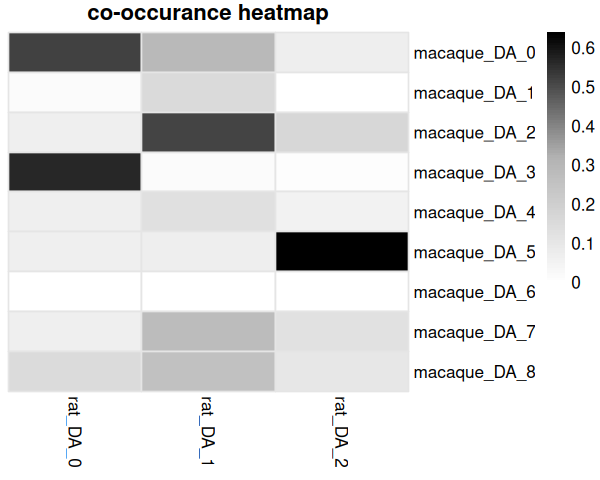

In [ ]:
GetCoCurMatrix <- function(x.tbl, tech.var = NULL){
    ratio_matrix <- x.tbl %>% setNames(c('species','cluster','seurat_clusters')) %>% mutate_if(is.factor, as.character) %>% 
        tidyr::unite(col = "term", c('species','cluster'),sep = '_') %>% group_by(term, seurat_clusters) %>%
        summarise(cell.num = dplyr::n()) %>% group_by(term) %>% mutate(ratio = cell.num/sum(cell.num)) %>% ungroup() %>% 
        select(-cell.num) %>% tidyr::pivot_wider(names_from = term,values_from = ratio, values_fill = 0) %>% 
        select(-seurat_clusters)
    
    x <- grep(paste0(tech.var[1],"_"),colnames(ratio_matrix),value = T)
    y <- grep(paste0(tech.var[2],"_"),colnames(ratio_matrix),value = T)
    
    co_cluster_matrix <- expand.grid(x, y) %>% 
        mutate(overlapScore = apply(.,1,FUN = function(i){
            sum(pmin(ratio_matrix[[i[[1]]]], ratio_matrix[[i[[2]]]]))
        })) %>% 
        tidyr::pivot_wider(names_from = "Var2", values_from = "overlapScore", values_fill = 0) %>% 
        tibble::column_to_rownames('Var1')
    
    return(co_cluster_matrix)
}

cocls.tbl1 <- integrated_data %>% FetchData(., vars = c('species','cluster','seurat_clusters')) 
cocur.obs1 <- GetCoCurMatrix(x.tbl = cocls.tbl1, tech.var = c('rat','macaque'))


GetCoCurRand <- function(x.tbl, tech.var = NULL, ech = 1e+3, cocur.obs1){
    x.tbl <- x.tbl %>% setNames(c('species','cluster','seurat_clusters')) %>% mutate_if(is.factor, as.character)
    pbapply::pblapply(1:ech, function(._){
        lapply(unique(x.tbl$species), function(.x){
            .sub <- x.tbl %>% filter(species == .x)
            mapping <- setNames(unique(.sub$seurat_clusters), sample(unique(.sub$seurat_clusters)))
            .sub <- .sub %>% mutate(seurat_clusters = recode(seurat_clusters, !!!mapping))
            {### 添加模拟噪音
                noise_index <- .sub %>% sample_frac(0.1) %>% row.names(.)
                .sub <- .sub %>% mutate(cluster = if_else(row.names(.) %in% noise_index, sample(cluster),cluster))
            }
            return(.sub)
        }) %>% bind_rows() -> shuffle_
        cocur.rand <- GetCoCurMatrix(x.tbl = shuffle_, tech.var = tech.var)
        cocur.rand <- cocur.rand[rownames(cocur.obs1),colnames(cocur.obs1)]
        return(cocur.rand)
    }) %>% suppressMessages()
}

cocur.rnd <- GetCoCurRand(x.tbl = cocls.tbl1, tech.var = c('rat','macaque'), cocur.obs1 = cocur.obs1)
p_values <- matrix(NA, nrow = nrow(cocur.obs1), ncol = ncol(cocur.obs1))
dimnames(p_values) <- list(rownames(cocur.obs1),colnames(cocur.obs1))
for (i in 1:nrow(cocur.obs1)) {
    for (j in 1:ncol(cocur.obs1)) {
        observed_value <- cocur.obs1[i, j]
        randomized_values <- purrr::map_dbl(cocur.rnd, ~ .x[i, j])
        test_result <- wilcox.test(randomized_values,mu = observed_value, alternative = "less", exact = F)
        p_values[i, j] <- test_result$p.value
    }
}
p_sign <- symnum(as.matrix(p_values), corr = FALSE, na = FALSE, 
                 cutpoints = c(0, 0.001, 0.01, 0.05, 0.1, 1), 
                 symbols = c("***", "**", "*", ".#", " "))


cocur.obs1_rename = cocur.obs1

# rownames(cocur.obs1_rename) <- gsub("^rat_", "", rownames(cocur.obs1_rename))
# colnames(cocur.obs1_rename) <- gsub("^macaque_", "", colnames(cocur.obs1_rename))

options(repr.plot.width = 5, repr.plot.height = 4)
{ ### 展示 OverlapRatio并保存热图
    pheatmap::pheatmap(
        t(cocur.obs1_rename), 
        main = "co-occurance heatmap", 
        border_color = "grey90",
        cluster_rows = F,
        cluster_cols = F,
        color = colorRampPalette(c("white", "grey70", "black"))(100),
        filename = "/mnt/90-connectome/Personal/CQW/motor_snRNA_new/article/EX_cellpaper_motor_co_heatmap_subclass.pdf", # 保存为PDF文件
        width = 5, height = 4
    )
}